# 04 · Host Behaviour

**Questions:** who supplies Amsterdam's Airbnb listings: individuals renting out their own home, or commercial operators? Who are the largest hosts, and how has supply grown over time?

**Host tiers** (based on `calculated_host_listings_count`, Inside Airbnb's count of a host's listings in Amsterdam):

| Tier | Listings per host |
|---|---|
| Individual | 1 |
| Small multi-host | 2–4 |
| Commercial | 5+ |

`is_multi_host` (from notebook 01) = Small multi-host + Commercial.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.style import (AQUA, BLUE, DATA_PROCESSED, NEUTRAL, ORANGE, ROOM_COLORS, SURFACE, TEXT_SECONDARY,
                       euro, save_fig, set_style)

set_style()
df = pd.read_csv(DATA_PROCESSED / "listings_clean.csv", parse_dates=["host_since", "last_scraped"])
TIERS = ["Individual (1)", "Small multi-host (2–4)", "Commercial (5+)"]
TIER_COLORS = dict(zip(TIERS, [BLUE, ORANGE, AQUA]))
df["host_tier"] = pd.cut(df["calculated_host_listings_count"], [0, 1, 4, np.inf], labels=TIERS)
print(f"{len(df):,} listings from {df['host_id'].nunique():,} hosts")

6,086 listings from 5,231 hosts


## 1. Individual vs multi-listing hosts

In [2]:
hosts = df.drop_duplicates("host_id")
share = pd.DataFrame({
    "% of listings": df["host_tier"].value_counts(normalize=True) * 100,
    "% of hosts": hosts["host_tier"].value_counts(normalize=True) * 100,
    "listings": df["host_tier"].value_counts(),
    "hosts": hosts["host_tier"].value_counts(),
}).reindex(TIERS).round(1)
share

,% of listings,% of hosts,listings,hosts
host_tier,,,,
Individual (1),78.1,90.8,4752,4752
Small multi-host (2–4),13.7,7.8,835,408
Commercial (5+),8.2,1.4,499,71


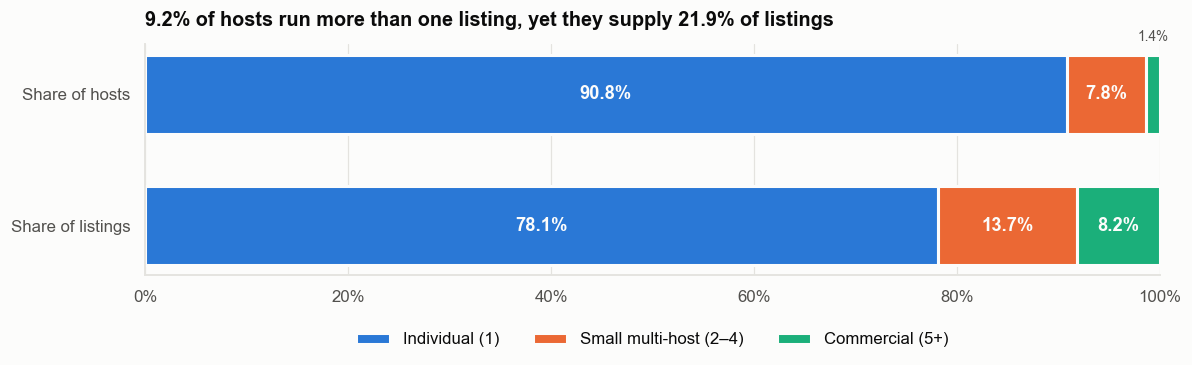

In [3]:
multi_listings = df["is_multi_host"].mean() * 100
multi_hosts = hosts["is_multi_host"].mean() * 100

fig, ax = plt.subplots(figsize=(11, 3.6))
for row, col in enumerate(["% of hosts", "% of listings"]):
    left = 0
    for tier in TIERS:
        v = share.loc[tier, col]
        ax.barh(row, v, left=left, color=TIER_COLORS[tier], height=0.6, edgecolor=SURFACE, linewidth=2,
                label=tier if row == 0 else None)
        if v >= 4:
            ax.text(left + v / 2, row, f"{v:.1f}%", ha="center", va="center", color=SURFACE, fontweight="bold")
        else:
            ax.text(left + v / 2, row - 0.38, f"{v:.1f}%", ha="center", va="bottom", color=TEXT_SECONDARY, fontsize=9)
        left += v
ax.set_yticks([0, 1], ["Share of hosts", "Share of listings"])
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0f}%")
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.18))
ax.set_title(f"{multi_hosts:.1f}% of hosts run more than one listing, yet they supply {multi_listings:.1f}% of listings")
plt.tight_layout()
save_fig(fig, "04_host_tier_share")
plt.show()

### How do the tiers differ?

In [4]:
profile = df.groupby("host_tier", observed=True).agg(
    listings=("id", "size"),
    median_price=("price", "median"),
    pct_entire_home=("room_type", lambda s: (s == "Entire home/apt").mean() * 100),
    median_days_available=("availability_365", "median"),
    median_reviews_ltm=("number_of_reviews_ltm", "median"),
    median_rating=("review_scores_rating", "median"),
    pct_superhost=("host_is_superhost", lambda s: s.mean() * 100),
    median_dist_centre_km=("dist_centre_km", "median"),
).round(2)
profile

,listings,median_price,pct_entire_home,median_days_available,median_reviews_ltm,median_rating,pct_superhost,median_dist_centre_km
host_tier,,,,,,,,
Individual (1),4752,316.15,87.04,89.0,3.0,4.94,17.11,2.52
Small multi-host (2–4),835,219.00,42.75,180.0,13.0,4.84,47.66,1.96
Commercial (5+),499,220.00,37.88,240.0,6.0,4.73,43.49,1.53


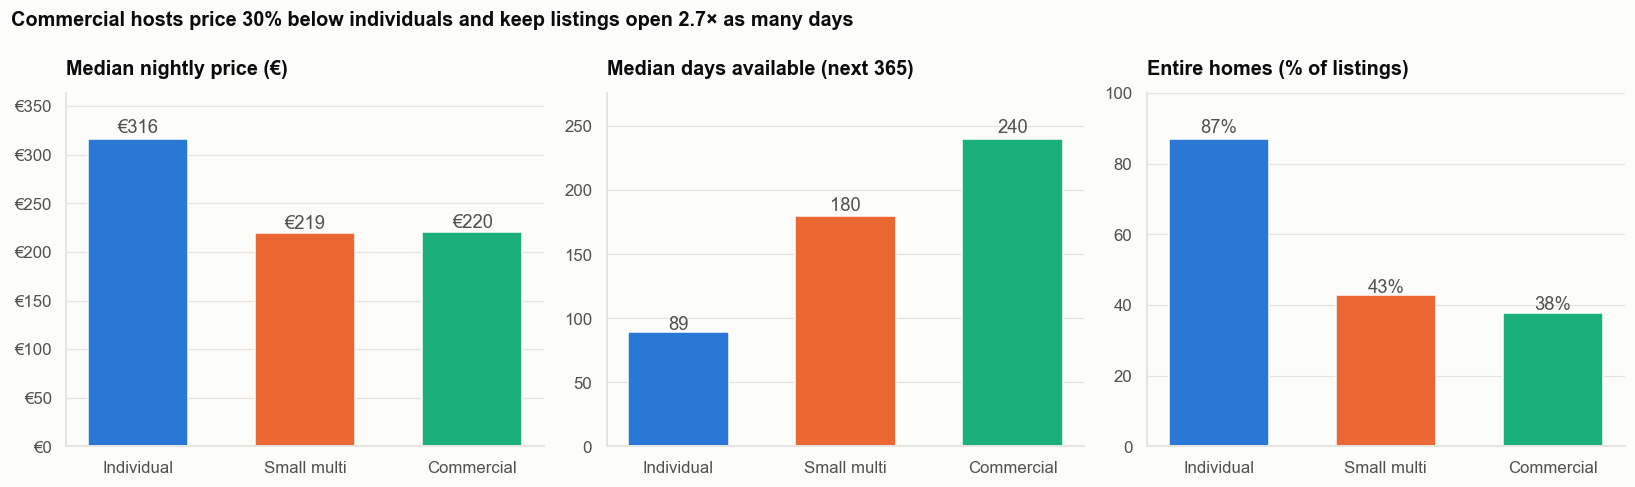

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
panels = [("median_price", "Median nightly price (€)", "€{:,.0f}"),
          ("median_days_available", "Median days available (next 365)", "{:,.0f}"),
          ("pct_entire_home", "Entire homes (% of listings)", "{:.0f}%")]
short = ["Individual", "Small multi", "Commercial"]
for ax, (col, label, fmt) in zip(axes, panels):
    vals = profile[col].values
    bars = ax.bar(short, vals, color=[TIER_COLORS[t] for t in TIERS], width=0.6)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v * 1.02, fmt.format(v), ha="center", color=TEXT_SECONDARY)
    ax.set(title=label, ylabel="")
    ax.title.set_fontsize(11.5)
    ax.set_ylim(0, vals.max() * 1.15)
    ax.grid(axis="x", visible=False)
axes[0].yaxis.set_major_formatter(euro)
fig.suptitle(f"Commercial hosts price {abs(profile.loc[TIERS[2], 'median_price'] / profile.loc[TIERS[0], 'median_price'] - 1):.0%} "
             f"{'below' if profile.loc[TIERS[2], 'median_price'] < profile.loc[TIERS[0], 'median_price'] else 'above'} individuals "
             f"and keep listings open {profile.loc[TIERS[2], 'median_days_available'] / max(profile.loc[TIERS[0], 'median_days_available'], 1):.1f}× as many days",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout()
save_fig(fig, "04_host_tier_profile")
plt.show()

## 2. Top 10 hosts by listing count
Counts are listings **in the cleaned dataset** (active, priced). Inside Airbnb's `calculated_host_listings_count` (all Amsterdam listings, including inactive ones) is shown for reference.

Hosts are **anonymised** as Host A–J (ranked by listing count). The analysis is about market structure, not individual hosts.

In [6]:
top = (df.groupby("host_id")
         .agg(listings=("id", "size"), all_listings=("calculated_host_listings_count", "max"),
              median_price=("price", "median"),
              main_room_type=("room_type", lambda s: s.mode().iloc[0]),
              main_neighbourhood=("neighbourhood_cleansed", lambda s: s.mode().iloc[0]),
              superhost=("host_is_superhost", "max"))
         .sort_values(["listings", "all_listings"], ascending=False).head(10).reset_index(drop=True))
top.insert(0, "label", [f"Host {chr(65 + i)}" for i in range(len(top))])
top

,label,listings,all_listings,median_price,main_room_type,main_neighbourhood,superhost
0,Host A,22,23,163.00,Private room,Centrum-Oost,False
1,Host B,15,15,181.00,Private room,Centrum-West,True
2,Host C,14,24,198.00,Private room,Oud-Oost,False
3,Host D,14,14,255.00,Private room,Centrum-Oost,True
4,Host E,14,14,167.75,Entire home/apt,Centrum-West,False
5,Host F,13,13,211.00,Entire home/apt,Geuzenveld - Slotermeer,True
6,Host G,12,14,454.35,Entire home/apt,Centrum-West,True
7,Host H,11,12,157.00,Private room,Centrum-Oost,False
8,Host I,11,11,249.00,Entire home/apt,Bos en Lommer,True
9,Host J,10,10,393.00,Entire home/apt,Centrum-West,False


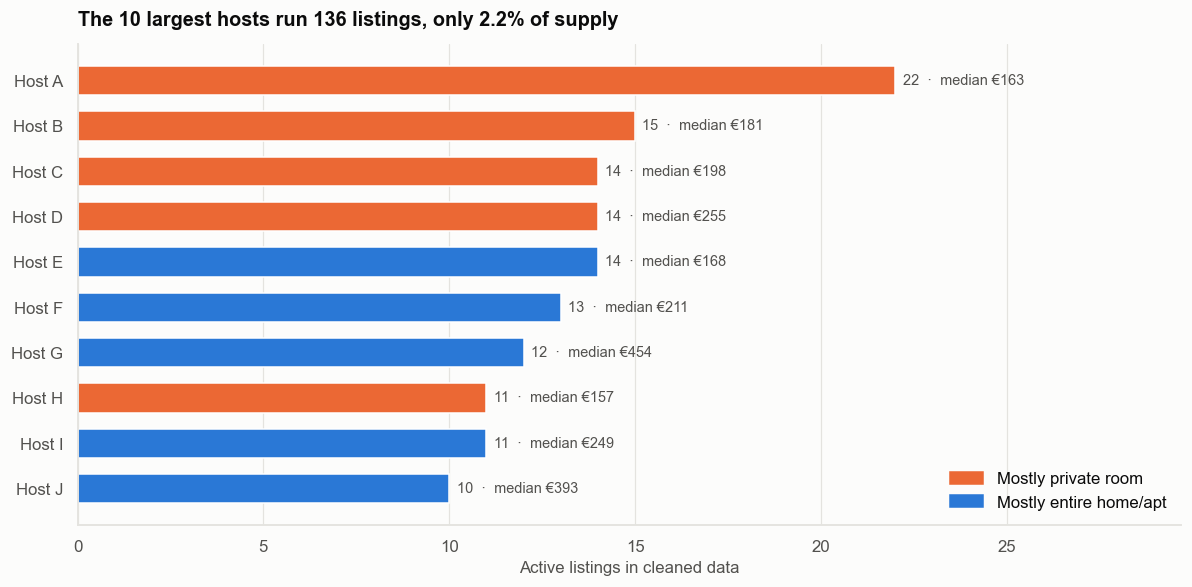

In [7]:
fig, ax = plt.subplots(figsize=(11, 5.5))
plot = top.iloc[::-1]
ax.barh(plot["label"], plot["listings"], color=[ROOM_COLORS[r] for r in plot["main_room_type"]], height=0.65)
for i, (n, p) in enumerate(zip(plot["listings"], plot["median_price"])):
    ax.text(n + 0.2, i, f"{n}  ·  median €{p:,.0f}", va="center", fontsize=9.5, color=TEXT_SECONDARY)
ax.set_xlim(0, top["listings"].max() * 1.35)
handles = [plt.Rectangle((0, 0), 1, 1, color=ROOM_COLORS[r]) for r in top["main_room_type"].unique()]
ax.legend(handles, [f"Mostly {r.lower()}" for r in top["main_room_type"].unique()], loc="lower right")
top10_share = top["listings"].sum() / len(df) * 100
ax.set(title=f"The 10 largest hosts run {top['listings'].sum()} listings, only {top10_share:.1f}% of supply",
       xlabel="Active listings in cleaned data", ylabel="")
ax.grid(axis="y", visible=False)
plt.tight_layout()
save_fig(fig, "04_top10_hosts")
plt.show()

## 3. Supply growth by host start year
`host_since` is empty in this scrape, so the start year is estimated from host tenure (`scrape date − hosts_time_as_host`). **Survivorship bias:** we only see hosts who are *still active* in 2026, so early years are under-counted. The chart shows when today's supply joined the platform, not how many listings existed each year. 2026 covers January–June only.

In [8]:
by_year = df.groupby("host_since_year").agg(listings=("id", "size"), hosts=("host_id", "nunique"))
by_year["cumulative_listings"] = by_year["listings"].cumsum()
by_year["% entire home"] = df.groupby("host_since_year")["room_type"].apply(lambda s: (s == "Entire home/apt").mean() * 100).round(1)
by_year["% multi-host"] = df.groupby("host_since_year")["is_multi_host"].mean().mul(100).round(1)
by_year

,listings,hosts,cumulative_listings,% entire home,% multi-host
host_since_year,,,,,
2011,79,66,79,62.0,34.2
2012,186,165,265,67.2,22.0
2013,267,228,532,68.9,24.7
2014,322,293,854,71.7,17.4
2015,391,359,1245,74.4,16.9
2016,431,374,1676,76.6,23.0
2017,405,348,2081,67.4,23.5
2018,402,300,2483,69.9,37.3
2019,389,306,2872,69.9,31.4


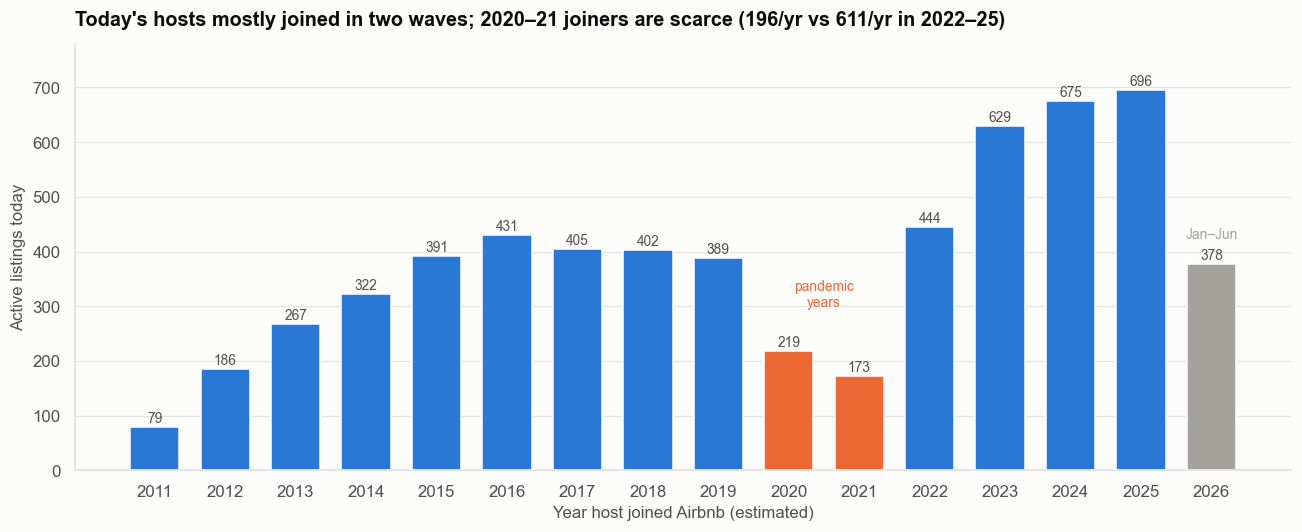

In [9]:
pre = by_year.loc[2016:2019, "listings"].mean()
dip = by_year.loc[2020:2021, "listings"].mean()
post = by_year.loc[2022:2025, "listings"].mean()

fig, ax = plt.subplots(figsize=(12, 5))
colors = [NEUTRAL if y == 2026 else (ORANGE if y in (2020, 2021) else BLUE) for y in by_year.index]
bars = ax.bar(by_year.index, by_year["listings"], color=colors, width=0.7)
for b, v in zip(bars, by_year["listings"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 8, f"{v}", ha="center", fontsize=9, color=TEXT_SECONDARY)
ax.set_ylim(0, by_year["listings"].max() * 1.12)
ax.set_xticks(by_year.index)
ax.set(title=f"Today's hosts mostly joined in two waves; 2020–21 joiners are scarce ({dip:.0f}/yr vs {post:.0f}/yr in 2022–25)",
       xlabel="Year host joined Airbnb (estimated)", ylabel="Active listings today")
ax.grid(axis="x", visible=False)
ax.text(2026, by_year.loc[2026, "listings"] + 45, "Jan–Jun", ha="center", color=NEUTRAL, fontsize=9)
ax.text(2020.5, by_year.loc[2020, "listings"] + 80, "pandemic\nyears", ha="center", color=ORANGE, fontsize=9)
plt.tight_layout()
save_fig(fig, "04_supply_growth")
plt.show()

In [10]:
recent = df["host_since_year"] >= 2022
print(f"Listings whose host joined 2022 or later: {recent.mean():.1%}")
print(f"Average joiners/yr: 2016–19 {pre:.0f}, 2020–21 {dip:.0f}, 2022–25 {post:.0f}")
print(f"Median price, hosts joined ≥2022: €{df.loc[recent, 'price'].median():.0f}  vs  before 2022: €{df.loc[~recent, 'price'].median():.0f}")
print(f"Median host tenure: {df['host_tenure_years'].median():.1f} years")

Listings whose host joined 2022 or later: 46.4%
Average joiners/yr: 2016–19 407, 2020–21 196, 2022–25 611
Median price, hosts joined ≥2022: €310  vs  before 2022: €281
Median host tenure: 5.7 years


## Key Takeaways

- **Mostly individuals, but multi-hosts punch above their weight:** 90.8% of hosts have a single listing; the 9.2% who run more than one supply **21.9%** of active listings. Commercial hosts (5+ listings) are just 1.4% of hosts (71) but 8.2% of listings.
- **Different business models:** individuals mostly rent entire homes (87%) for a few months a year (median 89 available days), priced at a median **€316**. Commercial hosts mostly rent rooms (only 38% entire homes), stay open **240 days** (2.7×) and price at **€220** (30% lower), closer to the centre (median 1.5 km vs 2.5 km from Dam Square).
- **Commercial hosts rate lower:** median rating 4.73 vs 4.94 for individuals, though 43% of commercial listings belong to superhosts (vs 17% for individuals).
- **No dominant operator:** the 10 largest hosts run 136 listings, just **2.2%** of supply. The largest (Host A) has 22 active listings, mostly private and hotel rooms at a median of €163.
- **Supply growth:** 46.4% of today's listings belong to hosts who joined in 2022 or later (~611 joiners/yr in 2022–25 vs ~196/yr in 2020–21, the pandemic years). Newer hosts' median price is €310 vs €281 for pre-2022 hosts. *Caveat:* start years are estimated from tenure and only include hosts still active, so earlier years are under-counted.